# Charting Boulder: BVSD Enrollment
[Brian C. Keegan, Ph.D.](http://www.brianckeegan.com)  
September 2026

Released under a [MIT License](https://opensource.org/licenses/MIT).

The Boulder Valley School District's [Resilient Schools](https://www.bvsd.org/about/resilient-schools)
proposal recommends closing four elementary schools; the board votes September 22, 2026. Its
background slide lists five causes of enrollment decline as a flat list — declining births
(labeled national, state and local), an aging population, low housing inventory, "high cost of
living," and cheaper housing in surrounding districts.

This notebook is the analysis behind a column arguing two things. First, that the district's own
data support two divergent and credible demographic futures, and that it should say which one it
is planning for. Second, that two items on that list — falling births and housing cost — are not
one natural fact and one man-made one; they move together with the same fifty years of land-use
policy. Every claim here is descriptive and correlational. Nothing in this notebook identifies a
causal effect of zoning on births, prices, or enrollment.

### Environment

Everything except two series reads from committed files under `data/`. House prices and income
come live from the [Federal Reserve Bank of St. Louis (FRED)](https://fred.stlouisfed.org/), and
one supplementary check reads the [American Community Survey](https://www.census.gov/programs-surveys/acs/)
through the [Census API](https://www.census.gov/data/developers.html). Both are free and both need
a key in an environment variable: `FRED_API_KEY` and `CENSUS_API_KEY`. Beyond a standard Anaconda
install this notebook uses only `requests`; `pip install requests` if it is missing.

In [1]:
import pandas as pd
import numpy as np

pd.options.display.max_columns = 100

%matplotlib inline
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors

import os, re, json, warnings, requests
from pathlib import Path
from collections import Counter

sb.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# Portfolio colors: city blue, county green, context gray; the two forecast forks get
# blue (the state's official view) and red (the cohort view this notebook computes).
CITY, COUNTY, CONTEXT = 'tab:blue', 'tab:green', 'tab:gray'
SDO_COLOR, HP_COLOR, ALT = 'tab:blue', 'tab:red', 'tab:orange'

RAW = Path('data/raw')
PROC = Path('data/processed')
OUT = Path('output')
OUT.mkdir(exist_ok=True)

# The board vote this column is pegged to. A date, not a computed value.
VOTE_DATE = 'September 22, 2026'
print('setup ok · vote date', VOTE_DATE)

setup ok · vote date September 22, 2026


## Load the place registry and the decennial age tables

The place registry names the 31 places this piece compares: the City of Boulder, the five other
Boulder County municipalities, and the 25-city peer basket carried over from the
[2025-06 population piece](https://github.com/brianckeegan/charting-boulder/tree/main/2025-06-population).
The age tables are built from [IPUMS NHGIS](https://www.nhgis.org/) decennial extracts by
`scripts/build_age_tables.py`. The 1990 and 2000 censuses publish single years of age only below
20, so the finest grain shared by all four censuses is 19 age groups.

In [2]:
# Load
places_df = pd.read_csv(RAW / 'places.csv', dtype={'place_fips': str, 'county_fips': str})
place_age_groups_df = pd.read_csv(PROC / 'place-age-groups.csv', dtype={'place_fips': str})
county_age_groups_df = pd.read_csv(PROC / 'county-age-groups.csv', dtype={'county_fips': str})
place_age_single_df = pd.read_csv(PROC / 'place-age-single.csv', dtype={'place_fips': str})

CENSUS_YEARS = [1990, 2000, 2010, 2020]
N_GROUPS = place_age_groups_df['age_group'].nunique()

# Integrity checks
assert len(places_df) == 31, f'expected 31 places; got {len(places_df)}'
assert places_df['place_fips'].is_unique and places_df['place_fips'].str.len().eq(7).all()
assert len(place_age_groups_df) == 31 * len(CENSUS_YEARS) * N_GROUPS, \
    f'expected 31 places x 4 censuses x {N_GROUPS} groups; got {len(place_age_groups_df)}'
# Broomfield County (08014) was created in 2001, so it has no 1990 or 2000 census record
assert len(county_age_groups_df) == 28 * len(CENSUS_YEARS) * N_GROUPS - 2 * N_GROUPS, \
    f'unexpected county row count: {len(county_age_groups_df)}'
assert len(place_age_single_df) == 31 * 3 * 20, f'unexpected single-year row count: {len(place_age_single_df)}'
for name, frame in [('place groups', place_age_groups_df), ('county groups', county_age_groups_df),
                    ('place single', place_age_single_df)]:
    assert frame['pop'].notna().all(), f'{name}: null population'
    assert frame['year'].isin(CENSUS_YEARS).all(), f'{name}: year outside the census years'
    assert len(frame) not in (256, 16_384, 65_536, 1_048_576), f'{name}: possible Excel truncation'

BOULDER = places_df.loc[places_df['name'] == 'Boulder', 'place_fips'].iloc[0]
PEER_FIPS = places_df.loc[places_df['tier'] == 2, 'place_fips'].tolist()
RING_FIPS = places_df.loc[(places_df['tier'] == 1) & (places_df['place_fips'] != BOULDER), 'place_fips'].tolist()
PLACE_NAME = places_df.set_index('place_fips')['name']
print(f'{len(places_df)} places: Boulder ({BOULDER}) + {len(RING_FIPS)} county ring + {len(PEER_FIPS)} peers')

# Inspect
place_age_groups_df.head()

31 places: Boulder (0807850) + 5 county ring + 25 peers


,place_fips,year,age_group,age_lo,age_hi,pop
0,0137000,1990,0-4,0,4,10562
1,0137000,1990,5-9,5,9,10516
2,0137000,1990,10-14,10,14,9893
3,0137000,1990,15-17,15,17,6076
4,0137000,1990,18-19,18,19,5810


### State Demography Office forecasts

The [Colorado State Demography Office](https://demography.dola.colorado.gov/assets/html/sdodata.html)
publishes the official Vintage 2024 county forecasts. Single-year-of-age population and
components of change run to 2060; the household projection stops at 2050 and is not extended
anywhere in this notebook. BVSD spans two counties, Boulder (SDO code 13) and Broomfield (14).

In [3]:
# Load — the first row of each SDO file is a vintage title line
sya_df = pd.read_csv(RAW / 'sdo' / 'sya-county.csv', skiprows=1)
components_df = pd.read_excel(RAW / 'sdo' / 'components-change-county.xlsx', skiprows=1)
households_df = pd.read_excel(RAW / 'sdo' / 'household-county.xlsx', skiprows=1)

BVSD_COUNTIES = [13, 14]

# Integrity checks
for name, frame, key in [('sya', sya_df, 'countyfips'), ('components', components_df, 'countyfips'),
                         ('households', households_df, 'area_code')]:
    frame[key] = frame[key].astype(int)
    assert set(BVSD_COUNTIES) <= set(frame[key]), f'{name}: missing a BVSD county'
    assert len(frame) not in (256, 16_384, 65_536, 1_048_576), f'{name}: possible Excel truncation'
assert sya_df['age'].between(0, 100).all(), 'sya: age outside 0-100'
assert sya_df['totalpopulation'].notna().all(), 'sya: null population'
assert sya_df['year'].between(1990, 2060).all() and components_df['year'].between(1970, 2060).all()

SDO_LAST_YEAR = int(sya_df['year'].max())
HOUSEHOLD_LAST_YEAR = int(households_df['year'].max())
print(f'SDO single-year age {sya_df.year.min()}-{SDO_LAST_YEAR} · '
      f'components {components_df.year.min()}-{components_df.year.max()} · '
      f'households {households_df.year.min()}-{HOUSEHOLD_LAST_YEAR}')
print('vintage note: single-year age is the Mar 2025 prep; components and households are Mar 2026. All Vintage 2024.')

SDO single-year age 1990-2060 · components 1970-2060 · households 2010-2050
vintage note: single-year age is the Mar 2025 prep; components and households are Mar 2026. All Vintage 2024.


In [4]:
# Resident child cohorts for the two BVSD counties
c0 = sya_df['countyfips'].isin(BVSD_COUNTIES)
bvsd_sya_df = sya_df.loc[c0]

def cohort(frame, lo, hi):
    return frame.loc[frame['age'].between(lo, hi)].groupby('year')['totalpopulation'].sum()

resident_df = pd.DataFrame({'age_0_4': cohort(bvsd_sya_df, 0, 4),
                            'age_5_10': cohort(bvsd_sya_df, 5, 10),
                            'age_5_17': cohort(bvsd_sya_df, 5, 17)})
resident_df.index.name = 'year'
resident_df.head()

,age_0_4,age_5_10,age_5_17
year,,,
1990,15999,18193,36200
1991,16043,18524,37256
1992,16308,19060,38669
1993,16655,19710,40332
1994,16757,20081,41448


## The district's own numbers, as a baseline

Before this notebook disagrees with the district about anything, it should reproduce what the
district already published. The anchors below are BVSD's own figures from the Resilient Schools
proposal and from the [NCES Common Core of Data](https://nces.ed.gov/ccd/).

The conversion from resident children to enrollment is a **capture ratio**: BVSD enrollment
divided by the resident children of the two counties it spans. Boulder County also contains St.
Vrain Valley territory, so this is a share, not a headcount of "BVSD kids."

In [5]:
# District anchors, all from BVSD's published figures
K12_ENROLL_2020_21 = 29_240      # NCES Common Core of Data, 2020-21 total enrollment
K5_ENROLL_2025_26 = 9_732        # Resilient Schools: K-5 served, non-charter
K5_CAPACITY_2025 = 14_585        # Resilient Schools: K-5 capacity, non-charter
UTIL_NOW, UTIL_POST = 0.68, 0.75  # districtwide K-5 utilization before and after the plan
LOSS_5YR = 1_670                 # the district's projected five-year enrollment loss
ELEM_SCHOOLS_POST = 29           # elementary sites remaining after four closures

# Capture ratios, anchored on the district's own counts
capture_k12 = K12_ENROLL_2020_21 / resident_df.loc[2020, 'age_5_17']
capture_k5 = K5_ENROLL_2025_26 / resident_df.loc[2025, 'age_5_10']

# Does the SDO-grounded model reproduce the district's own 2030 projection?
k5_2030_sdo = resident_df.loc[2030, 'age_5_10'] * capture_k5
util_2030_current = k5_2030_sdo / K5_CAPACITY_2025
k12_loss_2025_2030 = (resident_df.loc[2025, 'age_5_17'] - resident_df.loc[2030, 'age_5_17']) * capture_k12

print(f'capture ratio, K-12 (2020-21 anchor): {capture_k12:.3f}   K-5 (2025-26 anchor): {capture_k5:.3f}')
print(f'K-5 enrollment 2030 on SDO residents: {k5_2030_sdo:,.0f}')
print(f'2030 K-5 utilization on current capacity: {util_2030_current:.1%}  (the district projects 65%)')
print(f'five-year K-12 loss 2025-2030: {k12_loss_2025_2030:,.0f}  (the district projects {LOSS_5YR:,})')

capture ratio, K-12 (2020-21 anchor): 0.481   K-5 (2025-26 anchor): 0.437
K-5 enrollment 2030 on SDO residents: 9,349
2030 K-5 utilization on current capacity: 64.1%  (the district projects 65%)
five-year K-12 loss 2025-2030: 1,989  (the district projects 1,670)


## Is this happening everywhere? The peer comparison

The strong form of the "national decline" claim is that Boulder's enrollment is falling the way
every comparable city's is. Two decades of decennial counts test it directly. Level and change are
reported together: a place that already has few children has less room to fall.

The finding splits in two. The cohort already in the schools grew faster in Boulder than in the
median peer over the 2010s. The cohort behind it — children under five, who become kindergartners
five years later — fell faster in Boulder than in almost all of them.

In [6]:
# The 19 groups collapse to the 18 standard five-year bands: 15-17 and 18-19 merge into 15-19.
# Recovering 5-17 needs the share of 15-19 that is 15-17, which the source table reports.
GROUP_LO = list(range(0, 90, 5))
G = {lo: i for i, lo in enumerate(GROUP_LO)}

def load_age_vectors(frame, idcol):
    # {fips: {year: (vector of 18 five-year groups, share of 15-19 that is 15-17)}}
    out = {}
    for fips, group in frame.groupby(idcol):
        out[fips] = {}
        for year, gy in group.groupby('year'):
            vec = np.zeros(len(GROUP_LO))
            for lo, pop in zip(gy['age_lo'], gy['pop']):
                vec[G[15 if lo in (15, 18) else lo]] += pop
            pop_15_17 = gy.loc[gy['age_lo'] == 15, 'pop'].iloc[0]
            share = pop_15_17 / vec[G[15]] if vec[G[15]] > 0 else np.nan
            out[fips][int(year)] = (vec, share)
    return out

place_age = load_age_vectors(place_age_groups_df, 'place_fips')
county_age = load_age_vectors(county_age_groups_df, 'county_fips')

def band_5_17(vec, share): return vec[G[5]] + vec[G[10]] + share * vec[G[15]]
def under_5(vec): return vec[G[0]]

assert set(places_df['place_fips']) <= set(place_age), 'registry place missing from the age tables'
print(f'age vectors for {len(place_age)} places and {len(county_age)} counties, '
      f'{len(GROUP_LO)} five-year groups')

age vectors for 31 places and 28 counties, 18 five-year groups


In [7]:
# Observed level and change, both decades
records = []
for fips in places_df['place_fips']:
    row = {'place_fips': fips, 'name': PLACE_NAME[fips],
           'tier': int(places_df.set_index('place_fips').loc[fips, 'tier'])}
    for year in CENSUS_YEARS:
        vec, share = place_age[fips][year]
        row[f'sa_{year}'] = band_5_17(vec, share)
        row[f'u5_{year}'] = under_5(vec)
        row[f'share_{year}'] = band_5_17(vec, share) / vec.sum() * 100
    row['sa_chg_00_10'] = (row['sa_2010'] / row['sa_2000'] - 1) * 100
    row['sa_chg_10_20'] = (row['sa_2020'] / row['sa_2010'] - 1) * 100
    row['u5_chg_00_10'] = (row['u5_2010'] / row['u5_2000'] - 1) * 100
    row['u5_chg_10_20'] = (row['u5_2020'] / row['u5_2010'] - 1) * 100
    records.append(row)
observed_df = pd.DataFrame(records).set_index('place_fips')

def pct_steeper_than(series, value):
    # share of peers whose change is less negative than Boulder's
    return float((-series < -value).mean() * 100)

boulder_s = observed_df.loc[BOULDER]
peers_df = observed_df.loc[PEER_FIPS]

boulder_sa_chg_10_20 = boulder_s['sa_chg_10_20']
peer_sa_chg_10_20 = peers_df['sa_chg_10_20'].median()
boulder_u5_chg_10_20 = boulder_s['u5_chg_10_20']
peer_u5_chg_10_20 = peers_df['u5_chg_10_20'].median()
u5_steeper_pct = pct_steeper_than(peers_df['u5_chg_10_20'], boulder_u5_chg_10_20)

In [8]:
print('School-age (5-17), City of Boulder vs the 25-city peer basket')
print(f'  2000s: Boulder {boulder_s.sa_chg_00_10:+.1f}%   peer median {peers_df.sa_chg_00_10.median():+.1f}%')
print(f'  2010s: Boulder {boulder_sa_chg_10_20:+.1f}%   peer median {peer_sa_chg_10_20:+.1f}%'
      '   <- Boulder GREW, and faster than the median peer')
print('\nUnder-5, the cohort behind it')
print(f'  2000s: Boulder {boulder_s.u5_chg_00_10:+.1f}%   peer median {peers_df.u5_chg_00_10.median():+.1f}%')
print(f'  2010s: Boulder {boulder_u5_chg_10_20:+.1f}%   peer median {peer_u5_chg_10_20:+.1f}%'
      f'   <- steeper than {u5_steeper_pct:.0f}% of peers')
print(f'\nBoulder school-age share of population, 2020: {boulder_s.share_2020:.1f}% '
      f'(peer median {peers_df.share_2020.median():.1f}%)')
observed_df.loc[[BOULDER] + PEER_FIPS].sort_values('u5_chg_10_20')[
    ['name', 'share_2020', 'sa_chg_00_10', 'sa_chg_10_20', 'u5_chg_00_10', 'u5_chg_10_20']].round(1)

School-age (5-17), City of Boulder vs the 25-city peer basket
  2000s: Boulder -5.7%   peer median -4.0%
  2010s: Boulder +17.4%   peer median +10.8%   <- Boulder GREW, and faster than the median peer

Under-5, the cohort behind it
  2000s: Boulder +1.7%   peer median +9.0%
  2010s: Boulder -17.9%   peer median -4.8%   <- steeper than 84% of peers

Boulder school-age share of population, 2020: 10.4% (peer median 12.5%)


,name,share_2020,sa_chg_00_10,sa_chg_10_20,u5_chg_00_10,u5_chg_10_20
place_fips,,,,,,
0656000,Pasadena,11.7,-16.2,-11.0,-10.1,-22.1
1724582,Evanston,14.1,-5.7,9.6,-0.7,-21.5
0669070,Santa Barbara,12.3,-10.8,-6.1,-7.1,-21.0
0952000,New Haven,16.1,-10.0,5.4,4.6,-18.3
0807850,Boulder,10.4,-5.7,17.4,1.7,-17.9
4962470,Provo,14.5,9.2,7.3,4.5,-14.0
3711800,Chapel Hill,12.7,35.1,4.3,36.3,-13.9
4261000,Pittsburgh,10.2,-29.1,-10.8,-14.2,-10.8
2205000,Baton Rouge,14.9,-9.2,-7.3,-3.3,-10.8


The second measure is harder to explain away as a compositional accident. Apply each place's own
2010 child-per-adult ratios to its 2020 adult population, and compare the children it should have
had with the children it counted. This asks whether a place kept the families its own recent past
implies, holding its own fertility behaviour fixed.

In [9]:
# Children 0-9 in 2020 against what each place's own 2010 child ratios imply for its 2020 adults
FERT_0_4 = slice(G[15], G[40] + 1)   # residents 15-44 generate the 0-4 cohort
FERT_5_9 = slice(G[20], G[45] + 1)   # residents 20-49 generate the 5-9 cohort

def child_ratios(vec):
    return vec[G[0]] / vec[FERT_0_4].sum(), vec[G[5]] / vec[FERT_5_9].sum()

records = []
for fips in places_df['place_fips']:
    vec_2010, _ = place_age[fips][2010]
    vec_2020, _ = place_age[fips][2020]
    r0, r5 = child_ratios(vec_2010)
    implied = r0 * vec_2020[FERT_0_4].sum() + r5 * vec_2020[FERT_5_9].sum()
    actual = vec_2020[G[0]] + vec_2020[G[5]]
    records.append({'place_fips': fips, 'name': PLACE_NAME[fips],
                    'implied_0_9': implied, 'actual_0_9': actual,
                    'gap_pct': (actual / implied - 1) * 100})
implied_df = pd.DataFrame(records).set_index('place_fips')

boulder_implied_gap = implied_df.loc[BOULDER, 'gap_pct']
implied_steeper_pct = pct_steeper_than(implied_df.loc[PEER_FIPS, 'gap_pct'], boulder_implied_gap)
print('Children 0-9 in 2020 vs what each place\'s own 2010 child ratios imply')
print(f'  Boulder {boulder_implied_gap:+.1f}%   peer median {implied_df.loc[PEER_FIPS, "gap_pct"].median():+.1f}%')
print(f'  more negative than {implied_steeper_pct:.0f}% of peers')
implied_df.loc[[BOULDER] + PEER_FIPS].sort_values('gap_pct')[['name', 'implied_0_9', 'actual_0_9', 'gap_pct']].round(1).head(10)

Children 0-9 in 2020 vs what each place's own 2010 child ratios imply
  Boulder -14.7%   peer median -9.7%
  more negative than 92% of peers


,name,implied_0_9,actual_0_9,gap_pct
place_fips,,,,
0656000,Pasadena,14857.0,12458.0,-16.1
2754880,Rochester,18300.9,15598.0,-14.8
0807850,Boulder,8321.9,7095.0,-14.7
0827425,Fort Collins,18917.2,16232.0,-14.2
3719000,Durham,38434.1,33051.0,-14.0
4261000,Pittsburgh,29740.9,25620.0,-13.9
0669070,Santa Barbara,8761.1,7733.0,-11.7
0649670,Mountain View,10583.7,9359.0,-11.6
1724582,Evanston,8200.6,7255.0,-11.5


The 2020 census counted children by single year of age, so the pipeline is visible directly. In
Boulder each younger cohort is smaller than the one above it. In Madison and Cambridge the
youngest cohort is the largest.

0-4 per 100 of the 10-14 cohort, 2020: {'Boulder': 72.0, 'Madison': 116.0, 'Cambridge': 142.0}


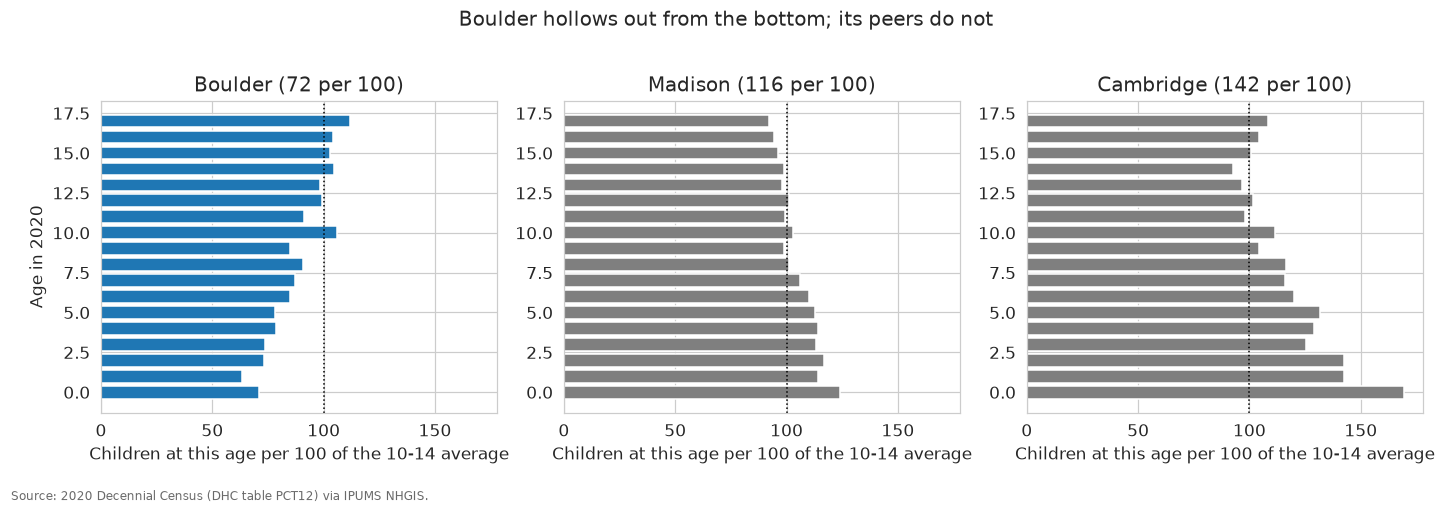

In [10]:
PYRAMID_PLACES = {'Boulder': '0807850', 'Madison': '5548000', 'Cambridge': '2511000'}
kids_2020_df = (place_age_single_df.loc[place_age_single_df['year'] == 2020]
                .pivot(index='age', columns='place_fips', values='pop'))
pyramid_df = pd.DataFrame({name: kids_2020_df[fips].loc[:17] for name, fips in PYRAMID_PLACES.items()})
pyramid_df.index.name = 'age'

# 0-4 per 100 of the 10-14 cohort: 100 means the pipeline is replacing itself
replacement_s = (pyramid_df.loc[0:4].sum() / pyramid_df.loc[10:14].sum() * 100).round(0)
boulder_replacement = replacement_s['Boulder']

f, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True)
for ax, city in zip(axes, PYRAMID_PLACES):
    indexed_s = pyramid_df[city] / pyramid_df[city].loc[10:14].mean() * 100
    ax.barh(pyramid_df.index, indexed_s, color=CITY if city == 'Boulder' else CONTEXT)
    ax.axvline(100, color='k', lw=1, ls=':')
    ax.set_title(f'{city} ({replacement_s[city]:.0f} per 100)')
    ax.set_xlabel('Children at this age per 100 of the 10-14 average')
axes[0].set_ylabel('Age in 2020')
f.suptitle('Boulder hollows out from the bottom; its peers do not', y=1.02)
f.text(0, -0.04, 'Source: 2020 Decennial Census (DHC table PCT12) via IPUMS NHGIS.', fontsize=8, color='dimgray')
plt.tight_layout()

print('0-4 per 100 of the 10-14 cohort, 2020:', replacement_s.to_dict())

### Would an annual series say more?

Four decennial points invite an obvious objection: the under-5 finding might be an artifact of
which two census years got compared. The American Community Survey publishes annual estimates for
places above 65,000 residents, which covers the City of Boulder and three of its peers, so the
objection is testable.

The next cell pulls Boulder's annual under-5 estimate with its margin of error, and the same
margin for the three eligible peers in the most recent year. It makes about twenty API calls and
takes under a minute.

In [11]:
CENSUS_URL = 'https://api.census.gov/data/{year}/acs/acs1'
# The Census Bureau released no standard one-year estimates for 2020
ACS_YEARS = [year for year in range(2008, 2025) if year != 2020]
ACS_PLACES = {'Boulder': ('08', '07850'), 'Fort Collins': ('08', '27425'),
              'Madison': ('55', '48000'), 'Ann Arbor': ('26', '03000')}

def acs_under_5(year, state_fips, place_fips):
    # B01001_003 is males under 5 and B01001_027 females under 5; the M variables are the
    # 90 percent margins of error, combined in quadrature because the two are independent.
    api_key = os.getenv('CENSUS_API_KEY')
    if not api_key:
        raise RuntimeError('Set the CENSUS_API_KEY environment variable (free from '
                           'https://api.census.gov/data/key_signup.html)')
    response = requests.get(CENSUS_URL.format(year=year), timeout=60, params={
        'get': 'B01001_003E,B01001_003M,B01001_027E,B01001_027M',
        'for': f'place:{place_fips}', 'in': f'state:{state_fips}', 'key': api_key})
    response.raise_for_status()
    male_est, male_moe, female_est, female_moe = [float(v) for v in response.json()[1][:4]]
    return male_est + female_est, float(np.hypot(male_moe, female_moe))

acs_boulder_df = pd.DataFrame(
    [dict(zip(('under_5', 'moe'), acs_under_5(year, *ACS_PLACES['Boulder'])), year=year)
     for year in ACS_YEARS]).set_index('year')
acs_boulder_df['moe_pct'] = acs_boulder_df['moe'] / acs_boulder_df['under_5'] * 100

acs_median_moe_pct = acs_boulder_df['moe_pct'].median()
acs_mean_abs_year_change = acs_boulder_df['under_5'].diff().abs().mean()
decennial_under5_change = abs(boulder_s['u5_2020'] - boulder_s['u5_2010'])

print(f'City of Boulder, ACS one-year under-5 estimate, {ACS_YEARS[0]}-{ACS_YEARS[-1]} (no 2020 release)')
print(f'  range {acs_boulder_df["under_5"].min():,.0f} to {acs_boulder_df["under_5"].max():,.0f}; '
      f'median margin of error {acs_median_moe_pct:.0f}% of the estimate')
print(f'  average year-to-year move {acs_mean_abs_year_change:,.0f} children, against a decennial '
      f'2010-to-2020 change of {decennial_under5_change:,.0f}')
acs_boulder_df.round(0)

City of Boulder, ACS one-year under-5 estimate, 2008-2024 (no 2020 release)
  range 1,939 to 4,990; median margin of error 23% of the estimate
  average year-to-year move 936 children, against a decennial 2010-to-2020 change of 708


,under_5,moe,moe_pct
year,,,
2008,4990.0,1251.0,25.0
2009,3905.0,906.0,23.0
2010,4274.0,937.0,22.0
2011,4461.0,1009.0,23.0
2012,3942.0,856.0,22.0
2013,3465.0,791.0,23.0
2014,3993.0,884.0,22.0
2015,2055.0,580.0,28.0
2016,4474.0,1003.0,22.0


In [12]:
# The same margin for every eligible peer in the latest year, to place Boulder's among them
latest_year = ACS_YEARS[-1]
latest_moe_s = pd.Series({name: acs_under_5(latest_year, *fips)[1] / acs_under_5(latest_year, *fips)[0] * 100
                          for name, fips in ACS_PLACES.items()}).sort_values()
print(f'Margin of error as a share of the under-5 estimate, {latest_year}:')
print(latest_moe_s.round(0).to_string())
print(f'\nBoulder is the smallest of the four and carries the widest margin. Its annual series moves '
      f'by more between consecutive years than the decennial count moved across the whole 2010s, so it '
      'cannot confirm or contradict the decennial trend. The four census points stand on their own, '
      'and no chart is drawn from this series.')

Margin of error as a share of the under-5 estimate, 2024:
Madison         14.0
Fort Collins    23.0
Ann Arbor       25.0
Boulder         31.0

Boulder is the smallest of the four and carries the widest margin. Its annual series moves by more between consecutive years than the decennial count moved across the whole 2010s, so it cannot confirm or contradict the decennial trend. The four census points stand on their own, and no chart is drawn from this series.


## The peg: what the district's list of causes leaves out

The Resilient Schools background slide gives five reasons enrollment is falling:

1. Declining births — labeled as national, state and local
2. An aging population
3. Low housing inventory
4. "High cost of living" — given no qualifier at all
5. Cheaper housing in surrounding districts

Read as a list, these are five separate headwinds, one of which is explicitly beyond anyone's
control and four of which are left unattributed. Two things the list flattens are worth naming.

The first is that only one item carries an origin. Births are marked national; housing inventory,
cost of living, and cheaper housing elsewhere are marked nothing at all — which invites the reader
to file them under the same heading.

The second is that items 1 and 4 are not independent. The section below shows falling births and
rising housing cost moving together in the same county over the same decades, alongside net
in-migration that stays positive throughout. A place that keeps importing adults while losing
children is not simply receiving a national fertility trend.

## The fork: two credible futures for the same children

There are two defensible ways to project the resident school-age population, and they disagree.

The State Demography Office builds its forecast from assumptions about births, deaths and
migration; it assumes fertility recovers after 2025. A **Hamilton-Perry** cohort-change projection
assumes nothing about births directly: it carries each five-year age group forward by the ratio
observed between the last two censuses, and generates the youngest groups from the child-per-adult
ratios of the launch year. Applied to Boulder and Broomfield counties from the 2020 census, it
carries the 2010s forward.

Neither is corrected toward the other. The gap between them is the finding.

$$P_{a+10,\,t+10} = P_{a,\,t} \cdot \mathrm{CCR}_{a}, \qquad
\mathrm{CCR}_{a} = \frac{P_{a,\,2020}}{P_{a-10,\,2010}}$$

In [13]:
MIN_DENOM = 20   # a launch cohort smaller than this yields no usable ratio
TOP = len(GROUP_LO) - 1
STEP = 10

def ccr_vintage(vec_t0, vec_t1):
    # Cohort-change ratios for one ten-year transition. The two child groups are generated
    # from child ratios instead, so they stay NaN here. The 85+ group pools 75+ at t0.
    ratios = np.full(TOP + 1, np.nan)
    for i in range(2, TOP):
        ratios[i] = vec_t1[i] / vec_t0[i - 2] if vec_t0[i - 2] >= MIN_DENOM else np.nan
    pool = vec_t0[TOP - 2:].sum()
    ratios[TOP] = vec_t1[TOP] / pool if pool >= MIN_DENOM else np.nan
    return ratios

def hp_project(history, launch, vintages, n_steps):
    # history: {year: vector}; vintages: [(t0, t1), ...] whose ratios are averaged
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)   # the two child rows are NaN by design
        ratios = np.nanmean([ccr_vintage(history[t0], history[t1]) for t0, t1 in vintages], axis=0)
    ratios[2:] = np.where(np.isnan(ratios[2:]), 1.0, ratios[2:])   # no usable vintage: carry unchanged
    r0, r5 = child_ratios(history[launch])
    projected, current = {}, history[launch].copy()
    for step in range(1, n_steps + 1):
        nxt = np.zeros(TOP + 1)
        for i in range(2, TOP):
            nxt[i] = current[i - 2] * ratios[i]
        nxt[TOP] = current[TOP - 2:].sum() * ratios[TOP]
        nxt[G[0]] = r0 * nxt[FERT_0_4].sum()
        nxt[G[5]] = r5 * nxt[FERT_5_9].sum()
        projected[launch + step * STEP] = nxt
        current = nxt
    return projected

print('Hamilton-Perry engine ready')

Hamilton-Perry engine ready


### Backtest before use

The engine is validated the way the archived `appendix/peer-projection.ipynb` validated it: build
ratios on the 2000-to-2010 transition, launch from 2010, project to 2020, and score against the
census. Extending the projection horizon to 2060 does not change this test, but it does change
what the test is worth — Hamilton-Perry is validated in the literature to roughly fifteen years,
and 2060 is forty years past the launch.

In [14]:
records = []
for fips in places_df['place_fips']:
    history = {year: place_age[fips][year][0] for year in CENSUS_YEARS}
    predicted = hp_project(history, 2010, [(2000, 2010)], 1)[2020]
    _, share_2010 = place_age[fips][2010]
    _, share_2020 = place_age[fips][2020]
    actual, pred = band_5_17(history[2020], share_2020), band_5_17(predicted, share_2010)
    records.append({'place_fips': fips, 'name': PLACE_NAME[fips],
                    'actual_5_17': actual, 'pred_5_17': pred, 'error_pct': (pred / actual - 1) * 100})
backtest_df = pd.DataFrame(records).set_index('place_fips')

backtest_median_abs_error = backtest_df.loc[PEER_FIPS + [BOULDER], 'error_pct'].abs().median()
print(f'Ten-year backtest (2000-2010 ratios, launched 2010, scored on 2020), school-age 5-17:')
print(f'  median absolute error across Boulder and its peers: {backtest_median_abs_error:.1f}%')
print(f'  mean signed error across peers: {backtest_df.loc[PEER_FIPS, "error_pct"].mean():+.1f}%')
print(f'  Boulder: predicted {backtest_df.loc[BOULDER, "pred_5_17"]:,.0f} vs actual '
      f'{backtest_df.loc[BOULDER, "actual_5_17"]:,.0f} ({backtest_df.loc[BOULDER, "error_pct"]:+.1f}%)')
backtest_df.sort_values('error_pct')[['name', 'actual_5_17', 'pred_5_17', 'error_pct']].round(1).head()

Ten-year backtest (2000-2010 ratios, launched 2010, scored on 2020), school-age 5-17:
  median absolute error across Boulder and its peers: 6.4%
  mean signed error across peers: -3.9%
  Boulder: predicted 9,492 vs actual 11,242 (-15.6%)


,name,actual_5_17,pred_5_17,error_pct
place_fips,,,,
0846355,Louisville,3780.0,2819.5,-25.4
0841835,Lafayette,5244.0,4194.3,-20.0
2511000,Cambridge,9207.0,7390.8,-19.7
0807850,Boulder,11242.0,9491.6,-15.6
2603000,Ann Arbor,11983.0,10195.5,-14.9


### The two forks to 2060

Both counties have census age tables for 2010 and 2020, so the cohort projection runs on the
district's actual two-county footprint using the 2010-to-2020 transition. The state's forecast for
the same two counties comes straight from the single-year-of-age file.

In [15]:
PROJ_YEARS = [2030, 2040, 2050, 2060]
BVSD_COUNTY_FIPS = ['08013', '08014']

# Combine the two counties into one age history, then project
county_history = {year: sum(county_age[fips][year][0] for fips in BVSD_COUNTY_FIPS)
                  for year in (2010, 2020)}
share_15_17_2020 = (sum(county_age[fips][2020][1] * county_age[fips][2020][0][G[15]] for fips in BVSD_COUNTY_FIPS)
                    / sum(county_age[fips][2020][0][G[15]] for fips in BVSD_COUNTY_FIPS))
hp_chain = {2020: county_history[2020], **hp_project(county_history, 2020, [(2010, 2020)], len(PROJ_YEARS))}

fork_df = pd.DataFrame({
    'hp_5_17': {year: band_5_17(vec, share_15_17_2020) for year, vec in hp_chain.items()},
    'sdo_5_17': {year: resident_df.loc[year, 'age_5_17'] for year in [2020] + PROJ_YEARS},
})
fork_df['gap_pct'] = (fork_df['hp_5_17'] / fork_df['sdo_5_17'] - 1) * 100
fork_df.index.name = 'year'

gap_2030 = fork_df.loc[2030, 'gap_pct']
gap_2050 = fork_df.loc[2050, 'gap_pct']
gap_2060 = fork_df.loc[2060, 'gap_pct']
gap_widens = gap_2060 > gap_2030

# The cohort fork carries the whole 2010s forward, not just its children. Its larger child count
# comes with a larger county: this is what it costs to read the red line as a future.
fork_df['hp_total'] = {year: vec.sum() for year, vec in hp_chain.items()}
fork_df['sdo_total'] = {year: sya_df.loc[sya_df['countyfips'].isin(BVSD_COUNTIES)
                                         & (sya_df['year'] == year), 'totalpopulation'].sum()
                        for year in [2020] + PROJ_YEARS}
total_gap_2060 = (fork_df.loc[2060, 'hp_total'] / fork_df.loc[2060, 'sdo_total'] - 1) * 100

In [16]:
print('Resident school-age population (5-17), Boulder + Broomfield counties')
print(f'  2020 base, census vs SDO estimate: {fork_df.loc[2020, "hp_5_17"]:,.0f} vs '
      f'{fork_df.loc[2020, "sdo_5_17"]:,.0f} ({fork_df.loc[2020, "gap_pct"]:+.1f}%)')
for year in PROJ_YEARS:
    print(f'  {year}: cohort {fork_df.loc[year, "hp_5_17"]:>7,.0f}   state {fork_df.loc[year, "sdo_5_17"]:>7,.0f}'
          f'   gap {fork_df.loc[year, "gap_pct"]:+6.1f}%')
print(f'\nThe gap {"widens" if gap_widens else "narrows"} across the horizon, from {gap_2030:+.1f}% at 2030 '
      f'to {gap_2060:+.1f}% at 2060, though not step by step: it narrows into 2050, which is where the '
      "state's assumed birth rebound lands.")
print(f'\nThe cohort fork also implies a bigger county: {fork_df.loc[2060, "hp_total"]:,.0f} residents in 2060 '
      f'against the state\'s {fork_df.loc[2060, "sdo_total"]:,.0f}, {total_gap_2060:+.0f}%. Its extra children '
      'come with extra adults, at roughly the growth rate the two counties recorded in the 2010s.')
fork_df.round(1)

Resident school-age population (5-17), Boulder + Broomfield counties
  2020 base, census vs SDO estimate: 60,925 vs 60,799 (+0.2%)
  2030: cohort  59,710   state  50,931   gap  +17.2%
  2040: cohort  66,300   state  51,591   gap  +28.5%
  2050: cohort  70,034   state  55,080   gap  +27.1%
  2060: cohort  72,898   state  52,276   gap  +39.4%

The gap widens across the horizon, from +17.2% at 2030 to +39.4% at 2060, though not step by step: it narrows into 2050, which is where the state's assumed birth rebound lands.

The cohort fork also implies a bigger county: 586,183 residents in 2060 against the state's 480,187, +22%. Its extra children come with extra adults, at roughly the growth rate the two counties recorded in the 2010s.


,hp_5_17,sdo_5_17,gap_pct,hp_total,sdo_total
year,,,,,
2020,60925.0,60799,0.2,404870.0,405450
2030,59709.9,50931,17.2,459567.1,419377
2040,66299.9,51591,28.5,503913.9,450042
2050,70034.2,55080,27.1,546025.5,470240
2060,72897.7,52276,39.4,586183.3,480187


The archived `appendix/peer-projection.ipynb` runs the same engine on Boulder County alone and
reports the cohort projection 23.6 percent above the state forecast at 2050. The figure here is
27.1 percent because it covers both counties BVSD spans; adding Broomfield, which grew faster than
Boulder County in the 2010s, widens the gap. The two numbers are the same method on two different
footprints, not a revision of one into the other.

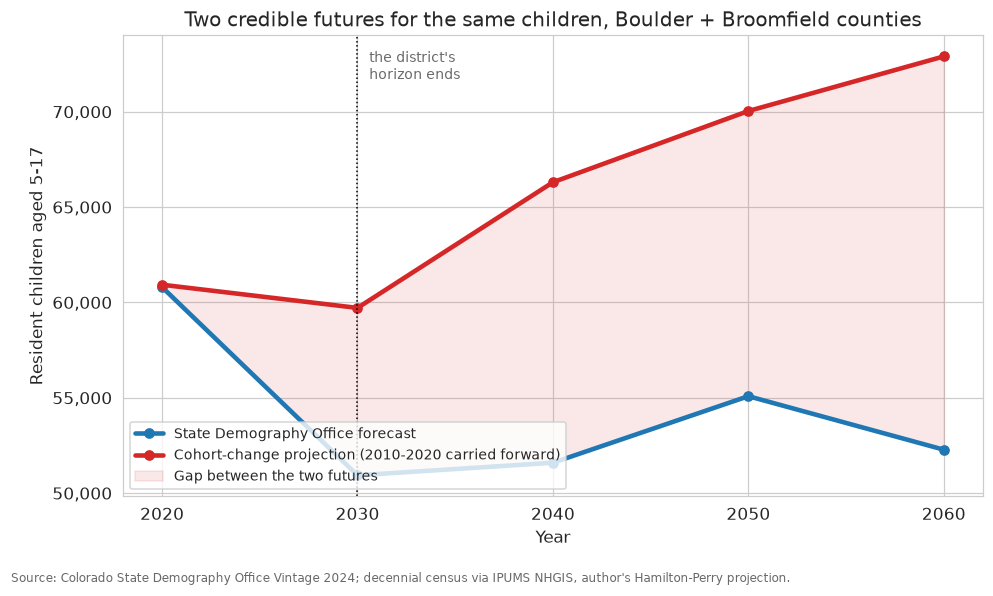

In [17]:
f, ax = plt.subplots(figsize=(9, 5.2))
years = [2020] + PROJ_YEARS
ax.plot(years, fork_df['sdo_5_17'], color=SDO_COLOR, lw=3, marker='o',
        label='State Demography Office forecast')
ax.plot(years, fork_df['hp_5_17'], color=HP_COLOR, lw=3, marker='o',
        label='Cohort-change projection (2010-2020 carried forward)')
ax.fill_between(years, fork_df['sdo_5_17'], fork_df['hp_5_17'],
                color=mcolors.to_rgba(HP_COLOR, 0.10), label='Gap between the two futures')
ax.axvline(2030, color='k', lw=1, ls=':')
ax.text(2030.6, ax.get_ylim()[1] * 0.99, "the district's\nhorizon ends", fontsize=9, color='dimgray', va='top')
ax.set_ylabel('Resident children aged 5-17')
ax.set_xlabel('Year')
ax.set_xticks(years)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_title('Two credible futures for the same children, Boulder + Broomfield counties')
ax.legend(loc='lower left', fontsize=9)
f.text(0, -0.03, 'Source: Colorado State Demography Office Vintage 2024; decennial census via IPUMS NHGIS, '
                 'author\'s Hamilton-Perry projection.', fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig1-two-futures.png', bbox_inches='tight')

## Where both futures come from: one mechanism, not two

The district's list separates falling births from high cost of living. The state's own components
of change put them in the same place.

Births in the two counties have fallen since 2000. Deaths overtake births within the forecast
period. And net migration stays positive throughout — the counties keep adding people, and keep
adding adults in particular. A county that grows by importing adults while its child cohorts
shrink is not simply receiving a national fertility trend; it is a place where the people arriving
are not the people who have children there, and where the people who would have are elsewhere.

That is the same fact the housing series below describes from the price side.

In [18]:
c0 = components_df['countyfips'].isin(BVSD_COUNTIES)
change_df = components_df.loc[c0].groupby('year')[['births', 'deaths', 'netmig']].sum()
change_df['natural_increase'] = change_df['births'] - change_df['deaths']

births_2000, births_2024 = change_df.loc[2000, 'births'], change_df.loc[2024, 'births']
births_change_pct = (births_2024 / births_2000 - 1) * 100
natural_decrease_year = int(change_df.loc[2020:].query('natural_increase < 0').index.min())
netmig_recent = change_df.loc[2015:2024, 'netmig'].mean()
netmig_forecast = change_df.loc[2025:2050, 'netmig'].mean()

print(f'births: {births_2000:,.0f} (2000) -> {births_2024:,.0f} (2024) = {births_change_pct:+.0f}%')
print(f'deaths overtake births in {natural_decrease_year}')
print(f'net migration: {netmig_recent:+,.0f}/yr observed 2015-2024 · {netmig_forecast:+,.0f}/yr forecast 2025-2050')
print('  -> the counties keep importing adults through the whole period the child cohorts shrink')
change_df.loc[[2000, 2010, 2020, 2024, 2030, 2040, 2050, 2060]].round(0)

births: 3,719 (2000) -> 2,980 (2024) = -20%
deaths overtake births in 2031
net migration: +2,368/yr observed 2015-2024 · +2,723/yr forecast 2025-2050
  -> the counties keep importing adults through the whole period the child cohorts shrink


,births,deaths,netmig,natural_increase
year,,,,
2000,3719,1388,28540,2331
2010,3831,1815,677,2016
2020,3149,2472,3280,677
2024,2980,2691,2690,289
2030,3129,3088,2871,41
2040,3546,3932,3164,-386
2050,3313,4523,2545,-1210
2060,3102,4850,2545,-1748


### Households with children

The share of households that contain a child is the cleanest single measure of whether a place is
one families live in. This series is the household projection, which the State Demography Office
publishes only through 2050. It is not extended past that year here, and it stops earlier than
every other series in this notebook for that reason.

In [19]:
c0 = households_df['area_code'].isin(BVSD_COUNTIES)
c1 = households_df['age_group_id'] == 0          # all householder ages
c2 = households_df['household_type_id'].isin([2, 4])   # one adult with kids, two-plus adults with kids
c3 = households_df['household_type_id'] == 0     # all households

households_kids_df = pd.DataFrame({
    'with_kids': households_df.loc[c0 & c1 & c2].groupby('year')['total_households'].sum(),
    'all_households': households_df.loc[c0 & c1 & c3].groupby('year')['total_households'].sum()})
households_kids_df['share_with_kids_pct'] = (households_kids_df['with_kids']
                                             / households_kids_df['all_households'] * 100)

hh_share_2010 = households_kids_df.loc[2010, 'share_with_kids_pct']
hh_share_2025 = households_kids_df.loc[2025, 'share_with_kids_pct']
hh_share_2050 = households_kids_df.loc[2050, 'share_with_kids_pct']
print(f'share of households with a child: {hh_share_2010:.1f}% (2010) -> {hh_share_2025:.1f}% (2025) '
      f'-> {hh_share_2050:.1f}% (2050)')
print(f'series ends at {HOUSEHOLD_LAST_YEAR}: the SDO household projection does not run to 2060, '
      'and is not extended here')
households_kids_df.loc[[2010, 2020, 2025, 2030, 2040, 2050]].round(1)

share of households with a child: 32.2% (2010) -> 27.6% (2025) -> 24.9% (2050)
series ends at 2050: the SDO household projection does not run to 2060, and is not extended here


,with_kids,all_households,share_with_kids_pct
year,,,
2010,45377,141066,32.2
2020,47510,163339,29.1
2025,46732,169028,27.6
2030,47451,176081,26.9
2040,49361,189768,26.0
2050,50046,200628,24.9


### Housing cost, 1975 to today

Two price series from [FRED](https://fred.stlouisfed.org/): the
[Boulder County house price index](https://fred.stlouisfed.org/series/ATNHPIUS08013A) back to
1975, the [Boulder MSA house price index](https://fred.stlouisfed.org/series/ATNHPIUS14500Q) back
to 1978, and [Boulder County median household income](https://fred.stlouisfed.org/series/MHICO08013A052NCEN)
back to 1989. The next cell calls the FRED API three times and needs `FRED_API_KEY` set.

In [20]:
FRED_URL = 'https://api.stlouisfed.org/fred/series/observations'

def fred_series(series_id):
    # Returns a float Series indexed by observation date. Raises if the key is missing or the
    # call fails; this notebook never substitutes a stand-in for a live series.
    api_key = os.getenv('FRED_API_KEY')
    if not api_key:
        raise RuntimeError('Set the FRED_API_KEY environment variable (free from '
                           'https://fred.stlouisfed.org/docs/api/api_key.html)')
    response = requests.get(FRED_URL, params={'series_id': series_id, 'api_key': api_key,
                                              'file_type': 'json'}, timeout=60)
    response.raise_for_status()
    observations = response.json()['observations']
    frame = pd.DataFrame(observations)
    values = pd.to_numeric(frame['value'], errors='coerce')     # FRED encodes missing as '.'
    return pd.Series(values.values, index=pd.to_datetime(frame['date']), name=series_id).dropna()

county_hpi_s = fred_series('ATNHPIUS08013A').groupby(lambda d: d.year).mean()
msa_hpi_s = fred_series('ATNHPIUS14500Q').groupby(lambda d: d.year).mean()
county_income_s = fred_series('MHICO08013A052NCEN').groupby(lambda d: d.year).mean()

# Integrity checks
for name, series, first_year in [('county HPI', county_hpi_s, 1975), ('MSA HPI', msa_hpi_s, 1978),
                                 ('median income', county_income_s, 1989)]:
    assert series.notna().all() and (series > 0).all(), f'{name}: bad values'
    assert series.index.min() == first_year, f'{name}: starts at {series.index.min()}, expected {first_year}'
print(f'county HPI {county_hpi_s.index.min()}-{county_hpi_s.index.max()} · '
      f'MSA HPI {msa_hpi_s.index.min()}-{msa_hpi_s.index.max()} · '
      f'median income {county_income_s.index.min()}-{county_income_s.index.max()}')
print('note: the county series is indexed to 2000=100 and the MSA series to 1995Q1=100 at source, '
      'so panel (b) below re-indexes both to 1989=100')

county HPI 1975-2025 · MSA HPI 1978-2026 · median income 1989-2024
note: the county series is indexed to 2000=100 and the MSA series to 1995Q1=100 at source, so panel (b) below re-indexes both to 1989=100


Panel (a) is the long view of Boulder County house prices, which no income series reaches back to
match. Panel (b) puts prices and incomes on the same index base for the years both exist. The
divergence in panel (b) is an indexed trend — the vertical distance is how much faster prices grew
than incomes since 1989, not a statement that houses cost some multiple of income. The two panels
also use different price geographies, county in (a) and metropolitan area in (b), because no MSA
series reaches back to 1975.

In [21]:
INDEX_BASE = 1989
both_years = sorted(set(msa_hpi_s.index) & set(county_income_s.index))
msa_indexed_s = msa_hpi_s.loc[both_years] / msa_hpi_s.loc[INDEX_BASE] * 100
income_indexed_s = county_income_s.loc[both_years] / county_income_s.loc[INDEX_BASE] * 100

price_income_ratio_2024 = msa_indexed_s.loc[2024] / income_indexed_s.loc[2024]
hpi_growth_since_1975 = county_hpi_s.loc[county_hpi_s.index.max()] / county_hpi_s.loc[1975]

Boulder County house prices are 17.7x their 1975 index level
since 1989, MSA prices have grown 2.5x as fast as county median income


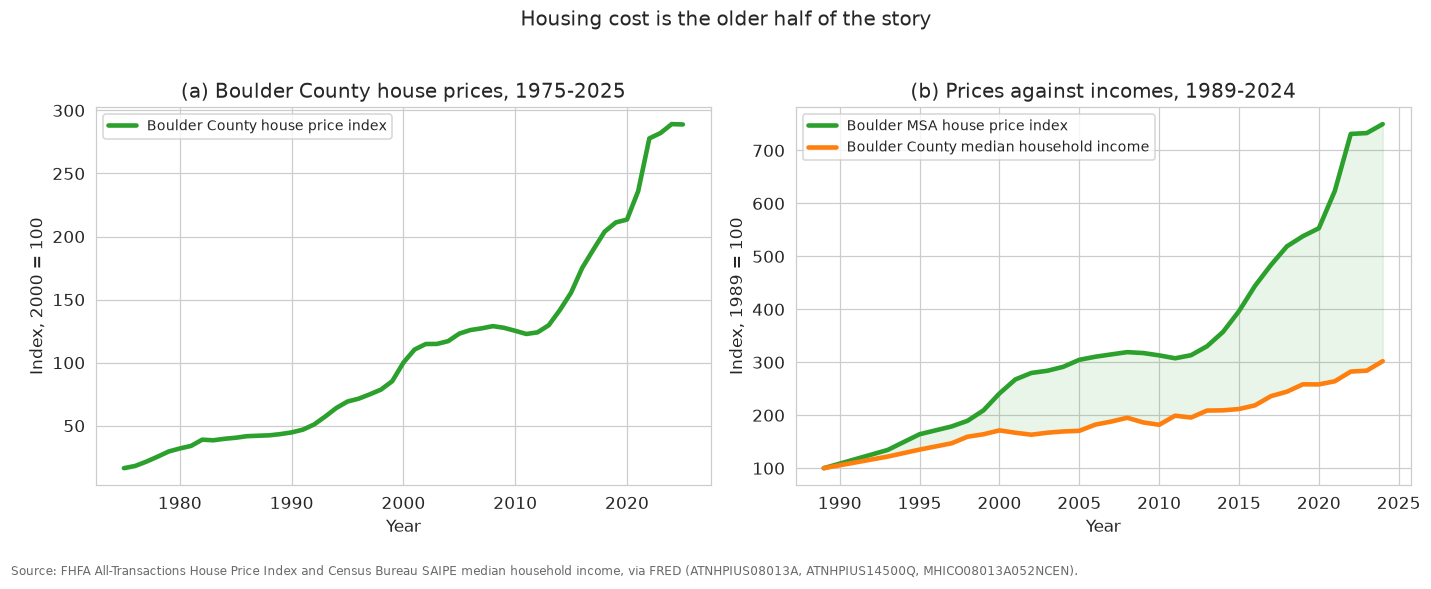

In [22]:
f, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.plot(county_hpi_s.index, county_hpi_s, color=COUNTY, lw=3, label='Boulder County house price index')
ax.set_ylabel('Index, 2000 = 100')
ax.set_xlabel('Year')
ax.set_title(f'(a) Boulder County house prices, {county_hpi_s.index.min()}-{county_hpi_s.index.max()}')
ax.legend(loc='upper left', fontsize=9)

ax = axes[1]
ax.plot(both_years, msa_indexed_s, color=COUNTY, lw=3, label='Boulder MSA house price index')
ax.plot(both_years, income_indexed_s, color=ALT, lw=3, label='Boulder County median household income')
ax.fill_between(both_years, income_indexed_s, msa_indexed_s,
                color=mcolors.to_rgba(COUNTY, 0.10))
ax.set_ylabel(f'Index, {INDEX_BASE} = 100')
ax.set_xlabel('Year')
ax.set_title(f'(b) Prices against incomes, {INDEX_BASE}-{both_years[-1]}')
ax.legend(loc='upper left', fontsize=9)

f.suptitle('Housing cost is the older half of the story', y=1.03)
f.text(0, -0.04, 'Source: FHFA All-Transactions House Price Index and Census Bureau SAIPE median household '
                 'income, via FRED (ATNHPIUS08013A, ATNHPIUS14500Q, MHICO08013A052NCEN).',
       fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig2-housing-cost.png', bbox_inches='tight')

print(f'Boulder County house prices are {hpi_growth_since_1975:.1f}x their 1975 index level')
print(f'since {INDEX_BASE}, MSA prices have grown {price_income_ratio_2024:.1f}x as fast as county median income')

### What the comprehensive plan talked about

The [Boulder Valley Comprehensive Plan](https://bouldercolorado.gov/services/boulder-valley-comprehensive-plan)
is the document where the city's land-use policy is written down, and it has been rewritten
repeatedly since 1977. Counting what its vocabulary attends to across editions is a descriptive
reading of what the policy conversation was about — not evidence that the plan caused any
demographic outcome.

The corpus is the Markdown conversion of fifteen editions, copied into `data/raw/bvcp/` from the
[2026-03 BVCP piece](https://github.com/brianckeegan/charting-boulder/tree/main/2026-03-bvcp).
Two of that piece's seventeen files are printings of the 1977 plan's 1978 revision — they share
79 to 83 percent of their sentences with each other — and are left out here.

The counting functions are ported from `bvcp-corpus-analysis.ipynb` with one change. That
notebook counts exact single tokens, which cannot see a phrase like "open space" or a stem like
"compatib"; sixteen of the twenty terms below would score zero under it. Terms are matched here as
phrases and word-prefixes over the cleaned text and normalized per 1,000 words of that same text.
Three terms proposed during outlining — "slow growth," "family with children," and "young famil" —
have no occurrences anywhere in the corpus and are dropped rather than carried as zeros.

In [23]:
BVCP_DIR = RAW / 'bvcp'
BVCP_EDITIONS = {
    'bvcp-1977-aug.md': ('1977', 1977), 'bvcp-1978-jun.md': ('1978', 1978),
    'bvcp-1979-jun.md': ('1979', 1979), 'bvcp-1981-may.md': ('1981', 1981),
    'bvcp-1983-oct.md': ('1983', 1983), 'bvcp-1986-oct.md': ('1986', 1986),
    'bvcp-1990-dec.md': ('1990', 1990), 'bvcp-1996-nov.md': ('1996', 1996),
    'bvcp-2001-sep.md': ('2001', 2001), 'bvcp-2005-dec.md': ('2005', 2005),
    'bvcp-2008.md': ('2008', 2008), 'bvcp-2010.md': ('2010', 2010),
    'bvcp-2015.md': ('2015', 2015), 'bvcp-2021-mar.md': ('2021', 2021),
    'bvcp-2026-mar.md': ('2026 draft', 2026),
}

def clean_text(md_text):
    # Strip markdown syntax, tables, page numbers and conversion artifacts
    text = re.sub(r'!\[.*?\]\(.*?\)', '', md_text)
    text = re.sub(r'\[([^\]]*)\]\([^\)]*\)', r'\1', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'^#{1,6}\s*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\*{1,3}([^*]+)\*{1,3}', r'\1', text)
    text = re.sub(r'\|', ' ', text)
    text = re.sub(r'^[-:]+$', '', text, flags=re.MULTILINE)
    text = re.sub(r'\.{3,}\s*\d+', '', text)
    return re.sub(r'\s+', ' ', text).strip()

corpus = {}
for filename, (label, year) in sorted(BVCP_EDITIONS.items(), key=lambda kv: kv[1][1]):
    text = clean_text((BVCP_DIR / filename).read_text(encoding='utf-8', errors='replace'))
    corpus[label] = {'year': year, 'clean': text, 'word_count': len(text.split())}

# Integrity checks
assert len(corpus) == 15, f'expected 15 editions; got {len(corpus)}'
assert all(info['word_count'] > 10_000 for info in corpus.values()), 'an edition converted to near-empty text'
print(f'{len(corpus)} editions, {sum(i["word_count"] for i in corpus.values()):,} words total')
pd.Series({info['year']: info['word_count'] for info in corpus.values()}, name='words')

15 editions, 707,475 words total


1977    22073
1978    36613
1979    40290
1981    50131
1983    52464
1986    52534
1990    54196
1996    61498
2001    70921
2005    53761
2008    57116
2010    36387
2015    40089
2021    54451
2026    24951
Name: words, dtype: int64

In [24]:
KEYWORD_FAMILIES = {
    'Preservation': ['neighborhood character', 'community character', 'preserve', 'preservation',
                     'open space', 'growth management', 'controlled growth', 'managed growth',
                     'compatib'],
    'Families & Schools': ['families with children', 'households with children', 'child care',
                           'childcare', 'school enrollment', 'enrollment', 'affordable housing',
                           'housing afford'],
}

def compute_family_rates(corpus, families):
    # Per-1,000-word rates, as in bvcp-corpus-analysis.ipynb, but matching each term as a
    # phrase or word-prefix over the cleaned text so multi-word terms and stems are visible.
    records = []
    for label, info in corpus.items():
        text, total = info['clean'].lower(), info['word_count']
        for family, terms in families.items():
            counts = {t: len(re.findall(r'\b' + re.escape(t).replace(r'\ ', r'\s+'), text)) for t in terms}
            raw = sum(counts.values())
            records.append({'version': label, 'year': info['year'], 'family': family,
                            'raw_count': raw, 'rate_per_1k': raw / total * 1000,
                            'top_term': max(counts, key=counts.get)})
    return pd.DataFrame(records)

family_rates_df = compute_family_rates(corpus, KEYWORD_FAMILIES)
assert (family_rates_df['raw_count'] > 0).all(), 'a family scored zero in some edition'

In [25]:
# 'open space' is a Boulder land-designation term of art as well as a preservation word, and it is
# the single largest contributor to the Preservation family. Reported so the ratio below is read
# with that in mind.
open_space_hits = sum(len(re.findall(r'\bopen\s+space', i['clean'].lower())) for i in corpus.values())
preservation_hits = family_rates_df.query('family == "Preservation"')['raw_count'].sum()
family_hits = family_rates_df.query('family == "Families & Schools"')['raw_count'].sum()
print(f'"open space" is {open_space_hits:,} of the {preservation_hits:,} Preservation mentions '
      f'({open_space_hits / preservation_hits:.0%})')
print(f'"affordable housing" also appears in the Housing family of the archived BVCP notebook, '
      'so the two families are not disjoint vocabularies')
family_rates_df.pivot(index='year', columns='family', values='rate_per_1k').round(2)

"open space" is 1,119 of the 2,949 Preservation mentions (38%)
"affordable housing" also appears in the Housing family of the archived BVCP notebook, so the two families are not disjoint vocabularies


family,Families & Schools,Preservation
year,,
1977,0.18,4.44
1978,0.11,3.17
1979,0.10,2.76
1981,0.08,2.83
1983,0.17,3.05
1986,0.17,3.14
1990,0.44,2.93
1996,0.47,3.87
2001,0.78,4.68


In [26]:
# The ratio the column cites, overall and split at the 2001 plan
preservation_by_year = family_rates_df.query('family == "Preservation"').set_index('year')
families_by_year = family_rates_df.query('family == "Families & Schools"').set_index('year')

ratio_overall = preservation_hits / family_hits
c0 = preservation_by_year.index < 2001
ratio_pre_2001 = preservation_by_year.loc[c0, 'raw_count'].sum() / families_by_year.loc[c0, 'raw_count'].sum()
ratio_post_2001 = preservation_by_year.loc[~c0, 'raw_count'].sum() / families_by_year.loc[~c0, 'raw_count'].sum()
ratio_widens = ratio_post_2001 > ratio_pre_2001

print(f'Preservation language per mention of families and schools, all 15 editions: {ratio_overall:.1f} to 1')
print(f'  editions before 2001: {ratio_pre_2001:.1f} to 1')
print(f'  2001 and after:       {ratio_post_2001:.1f} to 1')
print(f'  the gap {"widens" if ratio_widens else "narrows"} after 2001')

Preservation language per mention of families and schools, all 15 editions: 8.1 to 1
  editions before 2001: 13.7 to 1
  2001 and after:       6.4 to 1
  the gap narrows after 2001


Outlining this piece expected the gap between the two vocabularies to widen after 2001. Measured
across all fifteen editions with the phrase and prefix matching described above, it does the
opposite: preservation language runs about fourteen times the families-and-schools language in the
editions before 2001 and about six times in the editions from 2001 on. The ratio stays lopsided
throughout, and it is the level rather than the trend that the column can lean on.

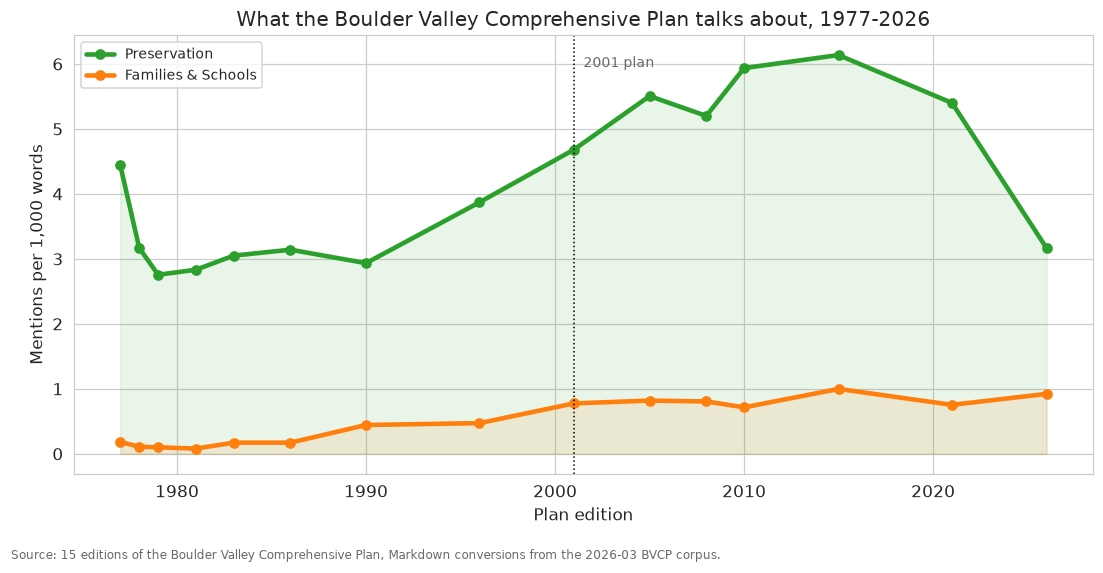

In [27]:
f, ax = plt.subplots(figsize=(10, 5))
for family, color in [('Preservation', COUNTY), ('Families & Schools', ALT)]:
    subset = family_rates_df.query('family == @family').sort_values('year')
    ax.plot(subset['year'], subset['rate_per_1k'], color=color, lw=3, marker='o', label=family)
    ax.fill_between(subset['year'], subset['rate_per_1k'], color=mcolors.to_rgba(color, 0.10))
ax.axvline(2001, color='k', lw=1, ls=':')
ax.text(2001.5, ax.get_ylim()[1] * 0.95, '2001 plan', fontsize=9, color='dimgray', va='top')
ax.set_ylabel('Mentions per 1,000 words')
ax.set_xlabel('Plan edition')
ax.set_title('What the Boulder Valley Comprehensive Plan talks about, 1977-2026')
ax.legend(loc='upper left', fontsize=9)
f.text(0, -0.03, 'Source: 15 editions of the Boulder Valley Comprehensive Plan, Markdown conversions '
                 'from the 2026-03 BVCP corpus.', fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig3-plan-vocabulary.png', bbox_inches='tight')

## What the close needs

The column's close asks the district to say which of the two futures it is planning for, and to
commit to one bounded round of closures. Both asks depend on numbers computed above. This section
carries each fork through the district's own arithmetic — the capture ratio, and the K-5 capacity
implied by the plan's own 68-to-75 percent utilization target — and reports when utilization
troughs under each.

The Hamilton-Perry projection reports five-year age groups, so its K-5 cohort takes the 5-9 group
plus a fifth of the 10-14 group. That is an assumption about ages within a group, and it is the
only interpolation anywhere in this notebook.

In [28]:
K5_CAPACITY_POST = K5_ENROLL_2025_26 / UTIL_POST     # capacity implied by the plan's 75% target

# The state's fork, annually
sdo_util_s = resident_df.loc[2025:, 'age_5_10'] * capture_k5 / K5_CAPACITY_POST * 100

# The cohort fork, at its ten-year steps. 2020 is the launch year, not a projection, so the
# trough is taken over the projected decades only.
hp_k5_s = pd.Series({year: vec[G[5]] + 0.2 * vec[G[10]] for year, vec in hp_chain.items()}).sort_index()
hp_util_s = (hp_k5_s * capture_k5 / K5_CAPACITY_POST * 100).loc[PROJ_YEARS]

sdo_trough_year, sdo_trough_util = int(sdo_util_s.idxmin()), sdo_util_s.min()
hp_trough_year, hp_trough_util = int(hp_util_s.idxmin()), hp_util_s.min()
# Same grid, so the two troughs are comparable rather than one annual and one decadal
sdo_util_decadal_s = sdo_util_s.reindex(PROJ_YEARS)
sdo_decadal_trough_year = int(sdo_util_decadal_s.idxmin())

print(f'post-plan K-5 capacity implied by the {UTIL_POST:.0%} target: {K5_CAPACITY_POST:,.0f} seats')
print(f'\nK-5 utilization of the post-consolidation system, state fork (annual, 2025-{SDO_LAST_YEAR})')
print(f'  trough {sdo_trough_util:.0f}% in {sdo_trough_year}; {sdo_util_s.loc[2060]:.0f}% by 2060')
print(f'\nOn the decades both forks share ({", ".join(str(y) for y in PROJ_YEARS)}):')
print(f'  state fork:  trough {sdo_util_decadal_s.min():.0f}% in {sdo_decadal_trough_year}, '
      f'{sdo_util_decadal_s.loc[2060]:.0f}% by 2060')
print(f'  cohort fork: trough {hp_trough_util:.0f}% in {hp_trough_year}, '
      f'{hp_util_s.loc[2060]:.0f}% by 2060')
print(f'\nThe two forks differ by {abs(hp_util_s.loc[2060] - sdo_util_s.loc[2060]):.0f} percentage points of '
      'utilization by 2060 on the same capacity. Under one the consolidated system settles near its '
      'target; under the other the district needs the seats back.')
print('The cohort fork moves in ten-year steps, so its trough year is resolved to a decade, not a year.')
pd.DataFrame({'state fork': sdo_util_decadal_s, 'cohort fork': hp_util_s}).round(1)

post-plan K-5 capacity implied by the 75% target: 12,976 seats

K-5 utilization of the post-consolidation system, state fork (annual, 2025-2060)
  trough 72% in 2029; 75% by 2060

On the decades both forks share (2030, 2040, 2050, 2060):
  state fork:  trough 72% in 2030, 75% by 2060
  cohort fork: trough 97% in 2030, 113% by 2060

The two forks differ by 38 percentage points of utilization by 2060 on the same capacity. Under one the consolidated system settles near its target; under the other the district needs the seats back.
The cohort fork moves in ten-year steps, so its trough year is resolved to a decade, not a year.


,state fork,cohort fork
2030,72.1,96.6
2040,78.3,103.6
2050,82.2,109.8
2060,75.1,112.9


## Pinned headline numbers

Every number the column cites appears below, computed from a cell above rather than typed in.
The table is written to `output/bvsd-pinned.csv`.

In [29]:
pinned_s = pd.Series({
    # The district's own baseline
    'vote_date': VOTE_DATE,
    'capture_ratio_k5_2025': round(capture_k5, 3),
    'capture_ratio_k12_2020': round(capture_k12, 3),
    'k5_2030_modeled': round(k5_2030_sdo),
    'util_2030_current_capacity_pct': round(util_2030_current * 100, 1),
    'k12_loss_2025_2030_modeled': round(k12_loss_2025_2030),
    'k12_loss_2025_2030_district': LOSS_5YR,
    # Peer comparison
    'boulder_5_17_change_2010_2020_pct': round(boulder_sa_chg_10_20, 1),
    'peer_median_5_17_change_2010_2020_pct': round(peer_sa_chg_10_20, 1),
    'boulder_under5_change_2010_2020_pct': round(boulder_u5_chg_10_20, 1),
    'peer_median_under5_change_2010_2020_pct': round(peer_u5_chg_10_20, 1),
    'boulder_under5_steeper_than_pct_of_peers': round(u5_steeper_pct),
    'boulder_0_9_vs_implied_2020_pct': round(boulder_implied_gap, 1),
    'boulder_0_9_gap_steeper_than_pct_of_peers': round(implied_steeper_pct),
    'boulder_0_4_per_100_of_10_14_2020': round(boulder_replacement),
    'acs_under5_median_moe_pct': round(acs_median_moe_pct, 1),
    'acs_under5_mean_abs_year_change': round(acs_mean_abs_year_change),
    'decennial_under5_change_2010_2020': round(decennial_under5_change),
    # The fork
    'backtest_median_abs_error_pct': round(backtest_median_abs_error, 1),
    'fork_5_17_sdo_2060': round(fork_df.loc[2060, 'sdo_5_17']),
    'fork_5_17_hp_2060': round(fork_df.loc[2060, 'hp_5_17']),
    'fork_gap_2030_pct': round(gap_2030, 1),
    'fork_gap_2050_pct': round(gap_2050, 1),
    'fork_gap_2060_pct': round(gap_2060, 1),
    # Mechanism
    'births_change_2000_2024_pct': round(births_change_pct, 1),
    'natural_decrease_first_year': natural_decrease_year,
    'net_migration_2015_2024_mean': round(netmig_recent),
    'households_with_kids_share_2010_pct': round(hh_share_2010, 1),
    'households_with_kids_share_2025_pct': round(hh_share_2025, 1),
    'households_with_kids_share_2050_pct': round(hh_share_2050, 1),
    'household_series_last_year': HOUSEHOLD_LAST_YEAR,
    'county_hpi_multiple_since_1975': round(hpi_growth_since_1975, 1),
    'price_vs_income_multiple_since_1989': round(price_income_ratio_2024, 1),
    'bvcp_preservation_to_families_ratio': round(ratio_overall, 1),
    'bvcp_ratio_pre_2001': round(ratio_pre_2001, 1),
    'bvcp_ratio_2001_onward': round(ratio_post_2001, 1),
    # The close
    'post_plan_k5_capacity': round(K5_CAPACITY_POST),
    'util_trough_year_sdo_fork': sdo_trough_year,
    'util_trough_pct_sdo_fork': round(sdo_trough_util, 1),
    'util_trough_year_hp_fork': hp_trough_year,
    'util_trough_pct_hp_fork': round(hp_trough_util, 1),
    'util_2060_pct_sdo_fork': round(sdo_util_s.loc[2060], 1),
    'util_2060_pct_hp_fork': round(hp_util_s.loc[2060], 1),
    'fork_total_population_gap_2060_pct': round(total_gap_2060, 1),
}, name='value')

pinned_s.to_csv(OUT / 'bvsd-pinned.csv')
fork_df.round(1).to_csv(OUT / 'bvsd-fork-5-17.csv')
observed_df.round(2).to_csv(OUT / 'bvsd-peer-observed.csv')
family_rates_df.round(3).to_csv(OUT / 'bvsd-plan-vocabulary.csv')
print(f'{len(pinned_s)} numbers pinned to {OUT / "bvsd-pinned.csv"}\n')
pinned_s.to_frame()

44 numbers pinned to output/bvsd-pinned.csv



,value
vote_date,"September 22, 2026"
capture_ratio_k5_2025,0.437
capture_ratio_k12_2020,0.481
k5_2030_modeled,9349
util_2030_current_capacity_pct,64.1
k12_loss_2025_2030_modeled,1989
k12_loss_2025_2030_district,1670
boulder_5_17_change_2010_2020_pct,17.4
peer_median_5_17_change_2010_2020_pct,10.8
boulder_under5_change_2010_2020_pct,-17.9


### What this notebook does not establish

1. **No causal claim.** The plan-vocabulary series, the price series and the demographic series are
   described together because they move together. Nothing here identifies an effect of land-use
   policy on births, prices, or enrollment.
2. **The cohort projection is not a forecast.** It carries the 2010-to-2020 transition forward
   unchanged. That decade contained the 2000s birth echo moving through Boulder's schools, so the
   projection inherits it. Hamilton-Perry is validated in the literature to roughly fifteen years;
   2060 is forty years past the launch, and the backtest error above is a floor on uncertainty
   rather than a confidence interval.
3. **The cohort fork's extra children come with extra adults.** Carrying the 2010s forward gives
   the two counties 22 percent more residents in 2060 than the state forecast does. Reading its
   child counts as a future means accepting that growth as well; it is not a claim that Boulder
   becomes more child-dense.
4. **The state forecast is not an observation either.** Its post-2025 recovery rests on assumptions
   about fertility and migration. Presenting both forks is the point; picking one silently would
   be the error.
5. **County is not district.** Boulder County contains St. Vrain Valley territory and Broomfield is
   split between districts. The capture ratio absorbs that as a share, anchored on one K-12 count
   and one K-5 count.
6. **The 2020 census distorts college towns.** April 2020 enumeration sent students home, which
   moves the 18-24 counts feeding the 2010-to-2020 cohort ratios for Boulder and much of its peer
   basket.
7. **Annexation sits inside the cohort ratios.** A place that grew by annexing family
   subdivisions shows cohort gains that are not migration into a fixed area. Boulder's growth
   boundary makes it unusually clean; several peers are not.
8. **The vocabulary counts are surface matches.** They count what the plan says, not what it did,
   and "open space" carries a Boulder-specific administrative meaning alongside its plain one.
9. **The annual survey cannot referee the decennial finding.** The American Community Survey's
   one-year under-5 estimate for a city of Boulder's size carries a margin of error near a quarter
   of the estimate, and swings between consecutive years by more than the decennial count moved
   across the whole 2010s. It is reported above as a check that failed to resolve, not as
   corroboration.